# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('CSV/california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [5]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

koloms = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

def check_plot(df_california, kolom):
    for kolom in koloms:
        plt.figure(figsize=(16, 4))
        plt.subplot(1, 2, 1)
        sns.histplot(df_california[kolom], bins=30)
        plt.title("Histogram")

        plt.subplot(1,2,2)
        sns.boxplot(x=df_california[kolom])
        plt.title(f'Outlier Detection of {kolom}')

        plt.tight_layout()
        plt.show()



### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

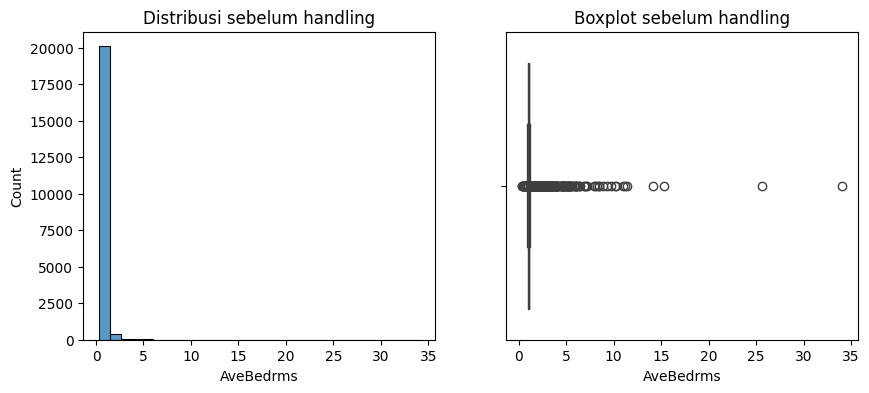

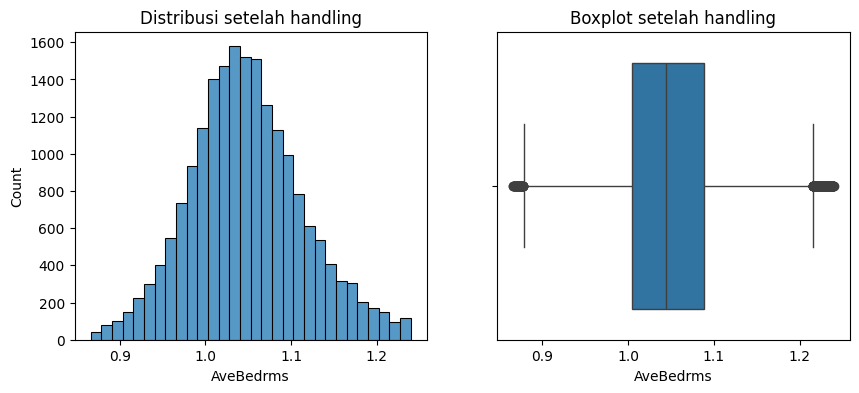

In [6]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
kolom = 'AveBedrms'

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_california[kolom], bins=30)
plt.title("Distribusi sebelum handling")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_california[kolom])
plt.title("Boxplot sebelum handling")

plt.show()

IQR = df_california[kolom].quantile(0.75) - df_california[kolom].quantile(0.25)
lower_boundary = df_california[kolom].quantile(0.25) - (IQR * 1.5)
upper_boundary = df_california[kolom].quantile(0.75) + (IQR * 1.5)

data_clean = df_california[(df_california[kolom] >= lower_boundary) & (df_california[kolom] <= upper_boundary)]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(data_clean[kolom], bins=30)
plt.title("Distribusi setelah handling")

plt.subplot(1, 2, 2)
sns.boxplot(x=data_clean[kolom])
plt.title("Boxplot setelah handling")

plt.show()


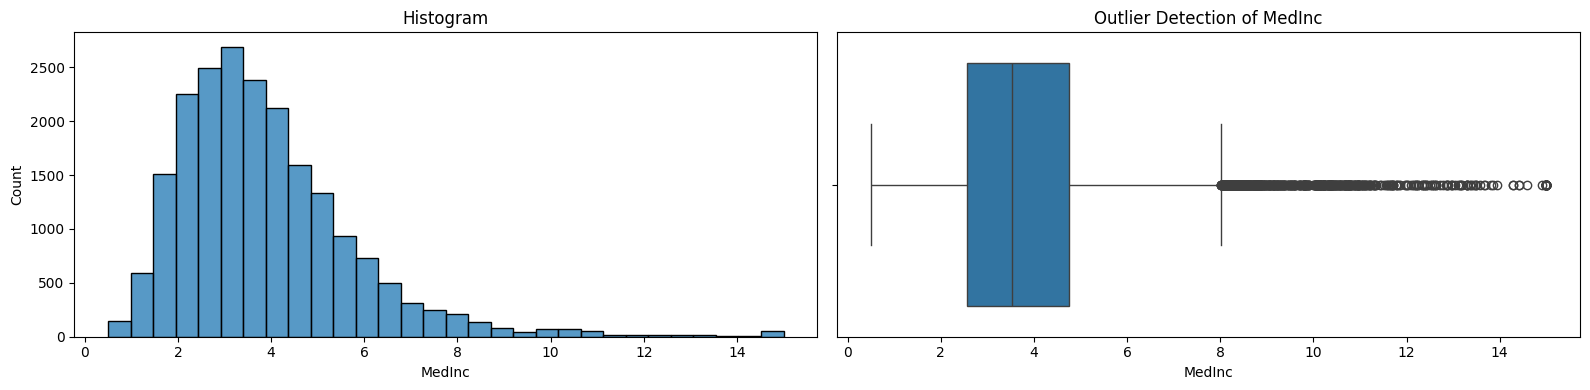

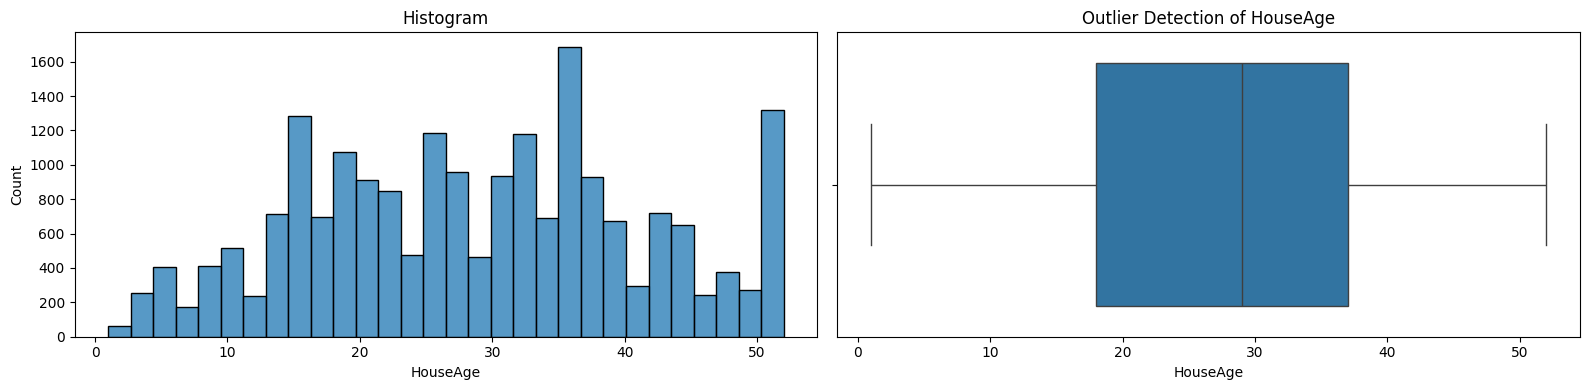

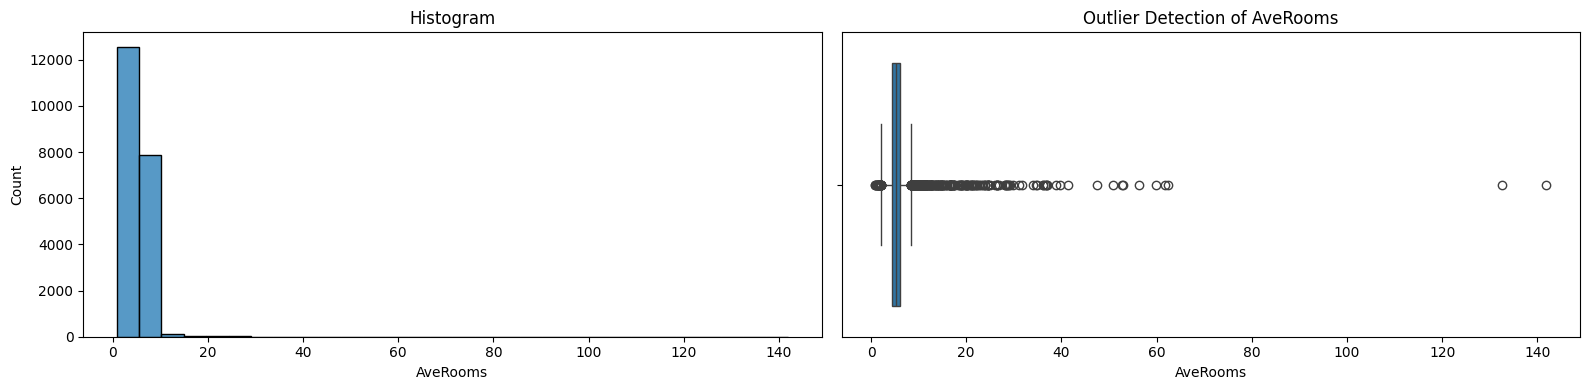

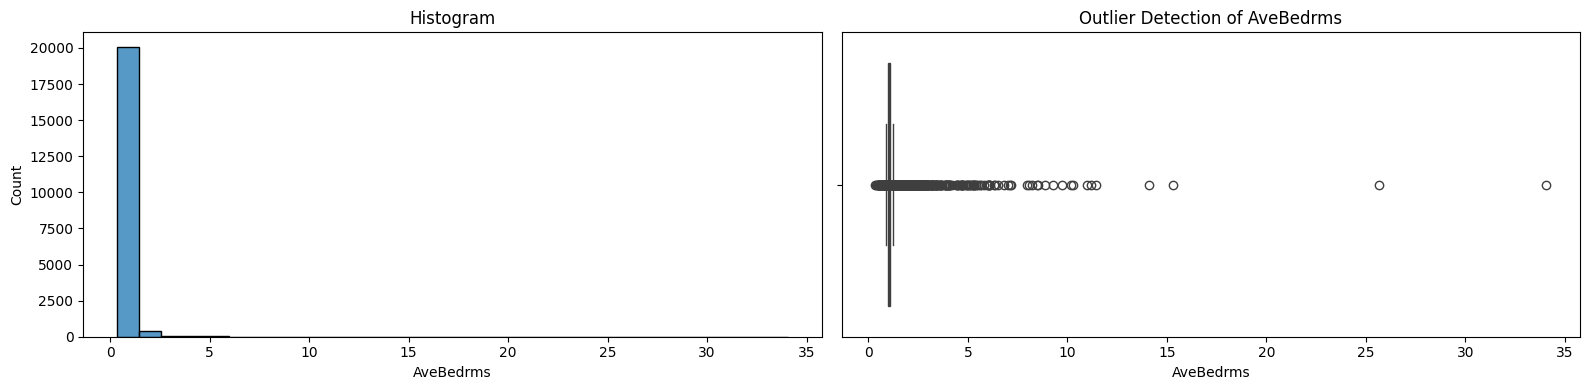

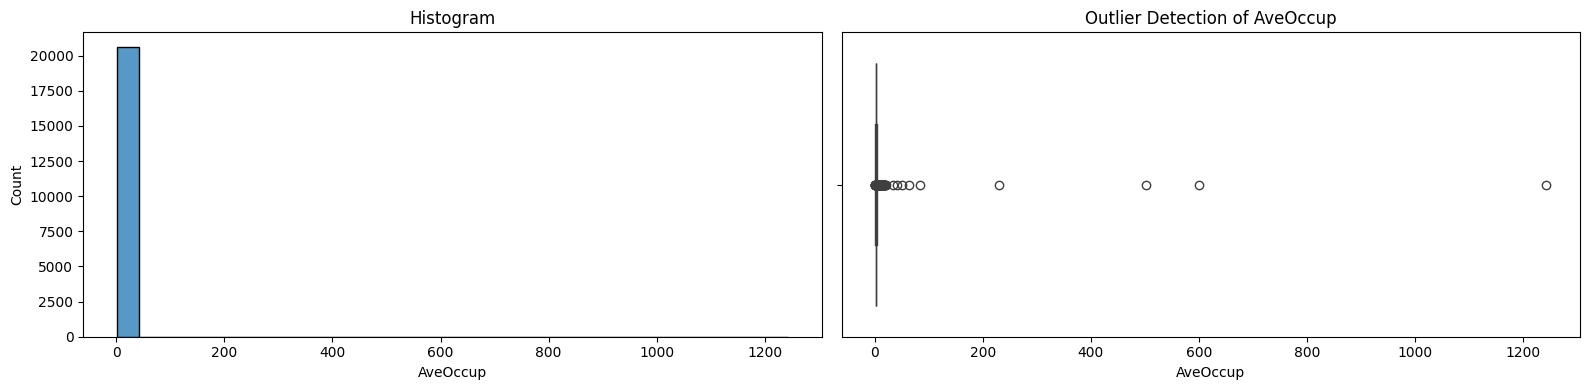

In [7]:
# Melakukan loop untuk mengecek distribusi tiap kolom
check_plot(df_california, koloms)


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [8]:
df_company = pd.read_csv('CSV/company.csv')
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [9]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
train_company, test_company = train_test_split(df_company, test_size= 0.2, random_state= 42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [10]:
#Tulis jawaban missing value handling kolom Headquarters disini

# Persentase missing value kolom Headquarters
100 * len(df_company[df_company['Headquarters']=='-1']) / len(df_company)
# Output dari persentase missing value sekitar 4,61% dimana itu < 20%



4.613095238095238

In [11]:
# Jenis missing value
df_company['Headquarters'].dtype

dtype('O')

In [12]:
modus = df_company['Headquarters'].mode()[0]
print("Nilai modus:", modus)

Nilai modus: New York, NY


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [13]:
df_churn = pd.read_csv('CSV/TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
#Splitting terlebih dahulu
train_telco, test_telco = train_test_split(df_churn, test_size= 0.2, random_state= 42)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [27]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
kolom_kolom = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

df_churn[kolom_kolom] = df_churn[kolom_kolom].replace("No internet service", "No")

In [28]:
for koloM in kolom_kolom:
    print(koloM)
    print(df_churn[koloM].value_counts())
    

StreamingMovies
StreamingMovies
0    2785
2    2732
1    1526
Name: count, dtype: int64
StreamingTV
StreamingTV
0    2810
2    2707
1    1526
Name: count, dtype: int64
TechSupport
TechSupport
0    3473
2    2044
1    1526
Name: count, dtype: int64
DeviceProtection
DeviceProtection
0    3095
2    2422
1    1526
Name: count, dtype: int64
OnlineBackup
OnlineBackup
0    3088
2    2429
1    1526
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
0    3498
2    2019
1    1526
Name: count, dtype: int64
MultipleLines
MultipleLines
0    3390
2    2971
1     682
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for koloM in kolom_kolom:
    df_churn[koloM] = label_encoder.fit_transform(df_churn[koloM])

In [30]:
df_churn[kolom_kolom].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,2,0,1
1,0,0,0,2,0,2,0
2,0,0,0,0,2,2,0
3,0,0,2,2,0,2,1
4,0,0,0,0,0,0,0


## Selesai :)